# Urban Green Score Project

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

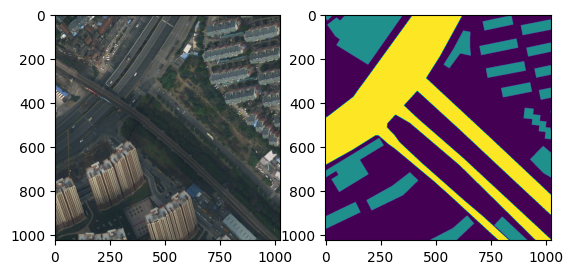

In [22]:
IMG_NUMBER = '1459'
IMG_DIR = 'dataset/train/Urban/images_png'
MASK_DIR = 'dataset/train/Urban/masks_png'

path_sat = IMG_DIR+'/'+IMG_NUMBER+'.png'
path_mask = MASK_DIR+'/'+IMG_NUMBER+'.png'

img_sat = np.asarray(Image.open(path_sat))
img_mask = np.asarray(Image.open(path_mask))

fig, axs = plt.subplots(1, 2)
axs[0].imshow(img_sat)
axs[1].imshow(img_mask)


['2319.png', '1579.png', '1857.png', '2046.png', '2284.png', '1706.png', '1564.png', '2053.png', '2055.png', '1956.png']


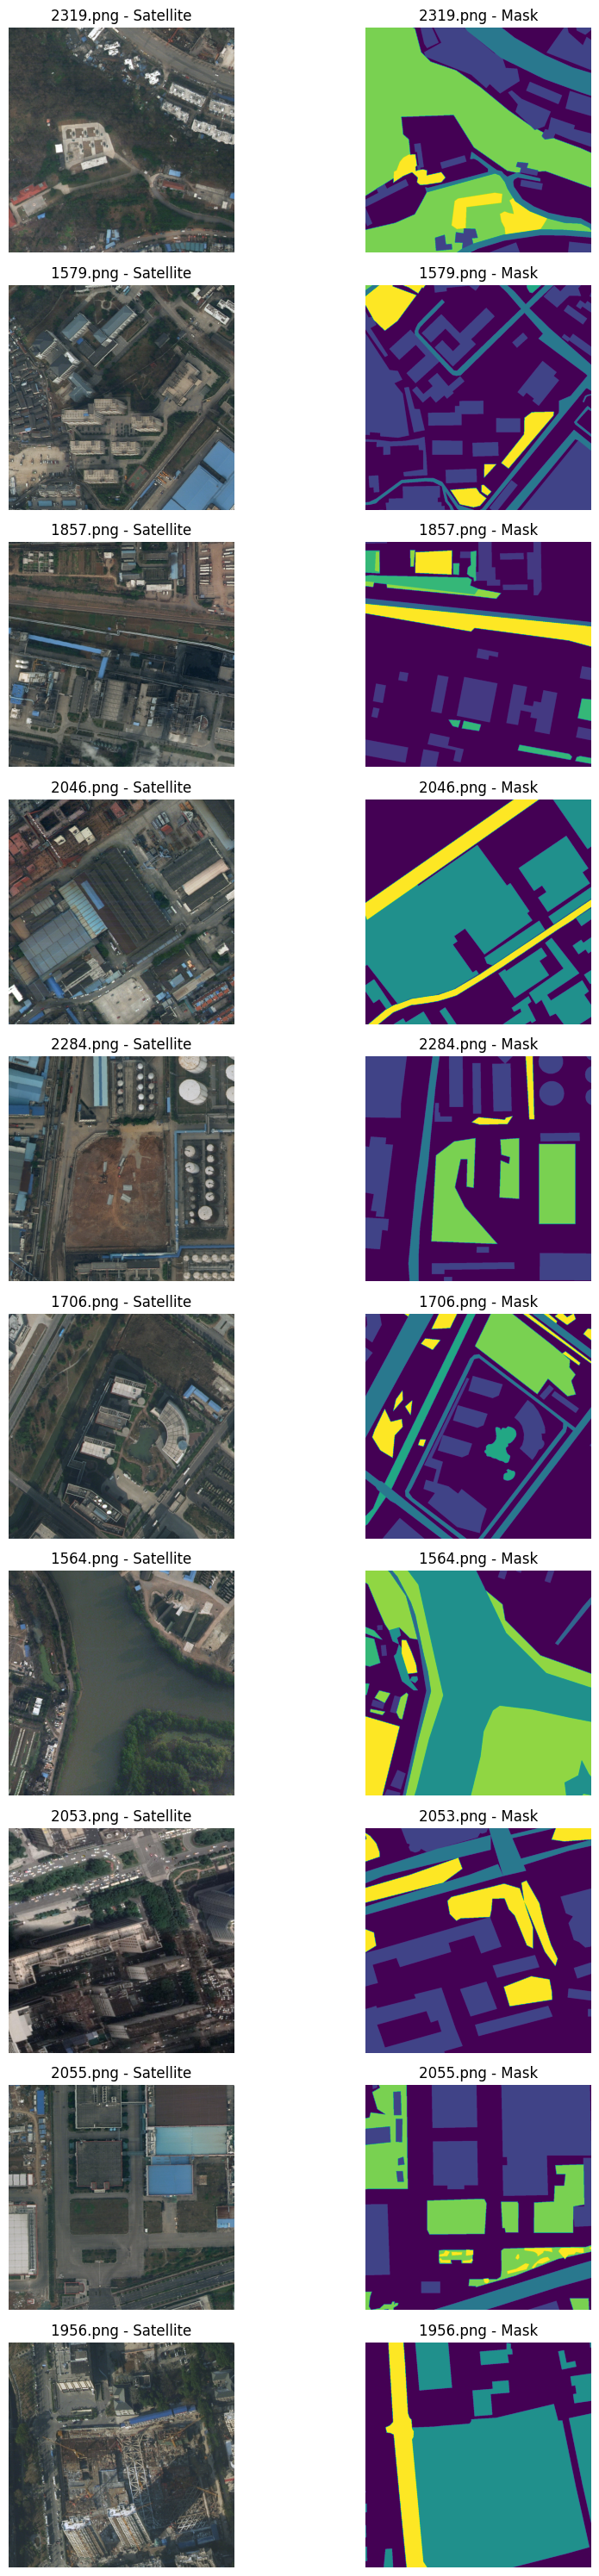

In [18]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = 'dataset/train/Urban/images_png'
MASK_DIR = 'dataset/train/Urban/masks_png'

# récupérer tous les fichiers _sat.jpg
sat_images = [f for f in os.listdir(IMG_DIR)]
mask_images = [f for f in os.listdir(MASK_DIR)]

# choisir 10 images aléatoires
sample_images = random.sample(sat_images, 10)
print(sample_images)

fig, axs = plt.subplots(10, 2, figsize=(10, 30))

for i, img_name in enumerate(sample_images):
    
    path_sat = os.path.join(IMG_DIR, img_name)
    path_mask = os.path.join(MASK_DIR, img_name)
    
    img_sat = np.asarray(Image.open(path_sat))
    img_mask = np.asarray(Image.open(path_mask))
    
    axs[i, 0].imshow(img_sat)
    axs[i, 0].set_title(f"{img_name} - Satellite")
    axs[i, 0].axis('off')
    
    axs[i, 1].imshow(img_mask)
    axs[i, 1].set_title(f"{img_name} - Mask")
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

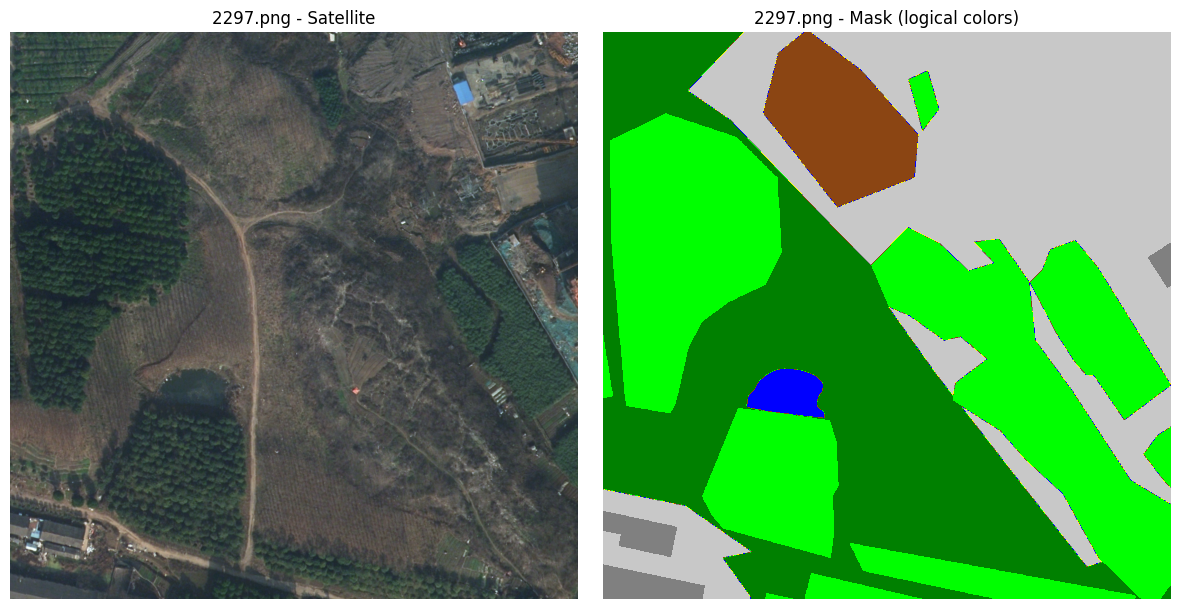


Class proportions:

background: 0.3064 (30.64%)
building: 0.0161 (1.61%)
road: 0.0000 (0.00%)
water: 0.0087 (0.87%)
barren: 0.0509 (5.09%)
forest: 0.3328 (33.28%)
agriculture: 0.2851 (28.51%)


In [43]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image

IMG_DIR = 'dataset/train/Urban/images_png'
MASK_DIR = 'dataset/train/Urban/masks_png'

CLASSES = {
    "background": 1,
    "building": 2,
    "road": 3,
    "water": 4,
    "barren": 5,
    "forest": 6,
    "agriculture": 7
}

IGNORE_LABEL = 0

# Colormap logique (index = label)
colors = [
    (0, 0, 0),        # 0 → no-data (noir)
    (200, 200, 200),  # 1 → background (gris clair)
    (128, 128, 128),  # 2 → building (gris)
    (255, 255, 0),    # 3 → road (jaune)
    (0, 0, 255),      # 4 → water (bleu)
    (139, 69, 19),    # 5 → barren (marron)
    (0, 255, 0),      # 6 → forest (vert)
    (0, 128, 0)       # 7 → agriculture (vert foncé)
]

colors = np.array(colors) / 255.0
cmap = ListedColormap(colors)

# récupérer images
images = [f for f in os.listdir(IMG_DIR) if f.endswith('.png')]
img_name = random.choice(images)

# chemins
path_sat = os.path.join(IMG_DIR, img_name)
path_mask = os.path.join(MASK_DIR, img_name)

# chargement
img_sat = np.asarray(Image.open(path_sat))
img_mask = np.asarray(Image.open(path_mask))

# affichage
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(img_sat)
axs[0].set_title(f"{img_name} - Satellite")
axs[0].axis('off')

axs[1].imshow(img_mask, cmap=cmap, vmin=0, vmax=7)
axs[1].set_title(f"{img_name} - Mask (logical colors)")
axs[1].axis('off')

plt.tight_layout()
plt.show()

# calcul proportions
H, W = img_mask.shape
valid_pixels = img_mask != IGNORE_LABEL
total_pixels = np.sum(valid_pixels)

print("\nClass proportions:\n")

for class_name, label in CLASSES.items():
    class_mask = (img_mask == label)
    count = np.sum(class_mask)
    ratio = count / total_pixels if total_pixels > 0 else 0
    
    print(f"{class_name}: {ratio:.4f} ({ratio*100:.2f}%)")